In [12]:
# CELLA 1 - Installazione (sklearn e openpyxl sono già presenti su Colab, ma per sicurezza)
!pip install -q scikit-learn openpyxl

In [13]:
# CELLA 2 - Caricamento dei due file Excel
from google.colab import files

print("Carica il primo file (es. DATA_SET_DEFINITIVO.xlsx)")
uploaded_a = files.upload()
file_a = list(uploaded_a.keys())[0]

print("Carica il secondo file (es. LORENZO.xlsx)")
uploaded_b = files.upload()
file_b = list(uploaded_b.keys())[0]

Carica il primo file (es. DATA_SET_DEFINITIVO.xlsx)


Saving DATA SET DEFINITIVO.xlsx to DATA SET DEFINITIVO (2).xlsx
Carica il secondo file (es. LORENZO.xlsx)


Saving LORENZO.xlsx to LORENZO (3).xlsx


In [14]:
# CELLA 3 - Caricamento dati e allineamento sulla colonna 'sentence'
import pandas as pd

df_a = pd.read_excel(file_a)
df_b = pd.read_excel(file_b)

print("Righe file A:", len(df_a))
print("Righe file B:", len(df_b))

# Allinea le righe usando la frase come chiave univoca
# (i due file possono avere le righe in ordine diverso)
merged = df_a.merge(df_b, on='sentence', suffixes=('_A', '_B'))
print("Righe allineate dopo il merge:", len(merged))

# Controllo: ci si aspetta che il numero di righe allineate
# corrisponda al numero di righe originali
if len(merged) != len(df_a) or len(merged) != len(df_b):
    print("ATTENZIONE: alcune frasi non corrispondono tra i due file!")

Righe file A: 160
Righe file B: 160
Righe allineate dopo il merge: 160


In [15]:
# CELLA 4 - Calcolo del Cohen's Kappa per ogni variabile annotata
from sklearn.metrics import cohen_kappa_score
from collections import Counter

# Modifica questa lista se le colonne hanno nomi diversi
colonne = ['information Status', 'Topic persistence', 'Discourse Hierarchy', 'Agentivity']

risultati = []

for col in colonne:
    col_a = merged[f'{col}_A']
    col_b = merged[f'{col}_B']

    # Esclude le righe dove almeno uno dei due ha un valore mancante
    mask = col_a.notna() & col_b.notna()
    a_clean = col_a[mask]
    b_clean = col_b[mask]

    k = cohen_kappa_score(a_clean, b_clean)
    accordo = (a_clean == b_clean).mean()

    risultati.append({
        'Variabile': col,
        'N': mask.sum(),
        'Escluse (mancanti)': (~mask).sum(),
        'Accordo osservato': round(accordo, 3),
        "Cohen's Kappa": round(k, 3)
    })

    print(f"\n--- {col} ---")
    print(f"N = {mask.sum()}  (escluse {(~mask).sum()} righe con valori mancanti)")
    print(f"Accordo osservato: {accordo:.3f}")
    print(f"Cohen's Kappa: {k:.3f}")
    print(f"Distribuzione A: {dict(Counter(a_clean))}")
    print(f"Distribuzione B: {dict(Counter(b_clean))}")

print("\n\n=== RIEPILOGO ===")
display(pd.DataFrame(risultati))


--- information Status ---
N = 160  (escluse 0 righe con valori mancanti)
Accordo osservato: 1.000
Cohen's Kappa: 1.000
Distribuzione A: {'new': 59, 'recap': 34, 'anchored': 67}
Distribuzione B: {'new': 59, 'recap': 34, 'anchored': 67}

--- Topic persistence ---
N = 160  (escluse 0 righe con valori mancanti)
Accordo osservato: 0.950
Cohen's Kappa: 0.912
Distribuzione A: {'setting': 78, 'discontinuous': 13, 'continuous': 69}
Distribuzione B: {'setting': 76, 'discontinuous': 11, 'continuous': 73}

--- Discourse Hierarchy ---
N = 160  (escluse 0 righe con valori mancanti)
Accordo osservato: 0.975
Cohen's Kappa: 0.950
Distribuzione A: {'A': 87, 'B': 73}
Distribuzione B: {'A': 87, 'B': 73}

--- Agentivity ---
N = 160  (escluse 0 righe con valori mancanti)
Accordo osservato: 0.856
Cohen's Kappa: 0.713
Distribuzione A: {'D': 84, 'C': 76}
Distribuzione B: {'D': 75, 'C': 85}


=== RIEPILOGO ===


,Variabile,N,Escluse (mancanti),Accordo osservato,Cohen's Kappa
0,information Status,160,0,1.000,1.000
1,Topic persistence,160,0,0.950,0.912
2,Discourse Hierarchy,160,0,0.975,0.950
3,Agentivity,160,0,0.856,0.713


In [16]:
# CELLA 5 (opzionale) - Esporta le frasi su cui i due annotatori NON sono d'accordo
disaccordi = {}

for col in colonne:
    col_a = merged[f'{col}_A']
    col_b = merged[f'{col}_B']
    mask_diff = (col_a != col_b) & col_a.notna() & col_b.notna()
    disaccordi[col] = merged.loc[mask_diff, ['sentence', f'{col}_A', f'{col}_B']]

# Esempio: vedere i disaccordi su Agentivity
display(disaccordi['Agentivity'])

# Per salvare tutto in un Excel con un foglio per variabile:
with pd.ExcelWriter('disaccordi.xlsx') as writer:
    for col, df_diff in disaccordi.items():
        df_diff.to_excel(writer, sheet_name=col[:31], index=False)

files.download('disaccordi.xlsx')

,sentence,Agentivity_A,Agentivity_B
2,"Postquam eo venit , quamquam persequi Iugurtha...",D,C
3,"Itaque non uti antea cum praedatoria manu , se...",D,C
8,"Ita Iugurthae placuerat , speranti mox effusos...",D,C
10,"Deinde ubi lux adventabat , DEFESSIS iam HOSTI...",C,D
13,"quid enim dicam benevolentiam , CUM illud ipsu...",C,D
18,"nemo nostrum est , ut opinor , quin vota victo...",C,D
29,"simus igitur ea mente , quam ratio et veritas ...",C,D
31,is CUM ex aliis te mei studiosissimum esse COG...,C,D
45,Iamque Pompeiani magna caede nostrorum castris...,D,C
46,His REBUS GESTIS Domitius sperans Scipionem ad...,D,C


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# CELLA 1
!pip install -q scikit-learn openpyxl

# CELLA 2 - upload file ed elaborazione (come prima)
from google.colab import files
import pandas as pd
from sklearn.metrics import cohen_kappa_score

uploaded_a = files.upload()
file_a = list(uploaded_a.keys())[0]
uploaded_b = files.upload()
file_b = list(uploaded_b.keys())[0]

df_a = pd.read_excel(file_a)
df_b = pd.read_excel(file_b)
merged = df_a.merge(df_b, on='sentence', suffixes=('_A', '_B'))

colonne = ['information Status', 'Topic persistence', 'Discourse Hierarchy', 'Agentivity']

dati = []
for col in colonne:
    a = merged[f'{col}_A']
    b = merged[f'{col}_B']
    mask = a.notna() & b.notna()
    k = cohen_kappa_score(a[mask], b[mask])
    dati.append((col, k, mask.sum()))

print(dati)

Saving DATA SET DEFINITIVO.xlsx to DATA SET DEFINITIVO (3).xlsx


Saving LORENZO.xlsx to LORENZO (4).xlsx
[('information Status', np.float64(1.0), np.int64(160)), ('Topic persistence', np.float64(0.9116754071211703), np.int64(160)), ('Discourse Hierarchy', np.float64(0.949614233978901), np.int64(160)), ('Agentivity', np.float64(0.7133956386292835), np.int64(160))]


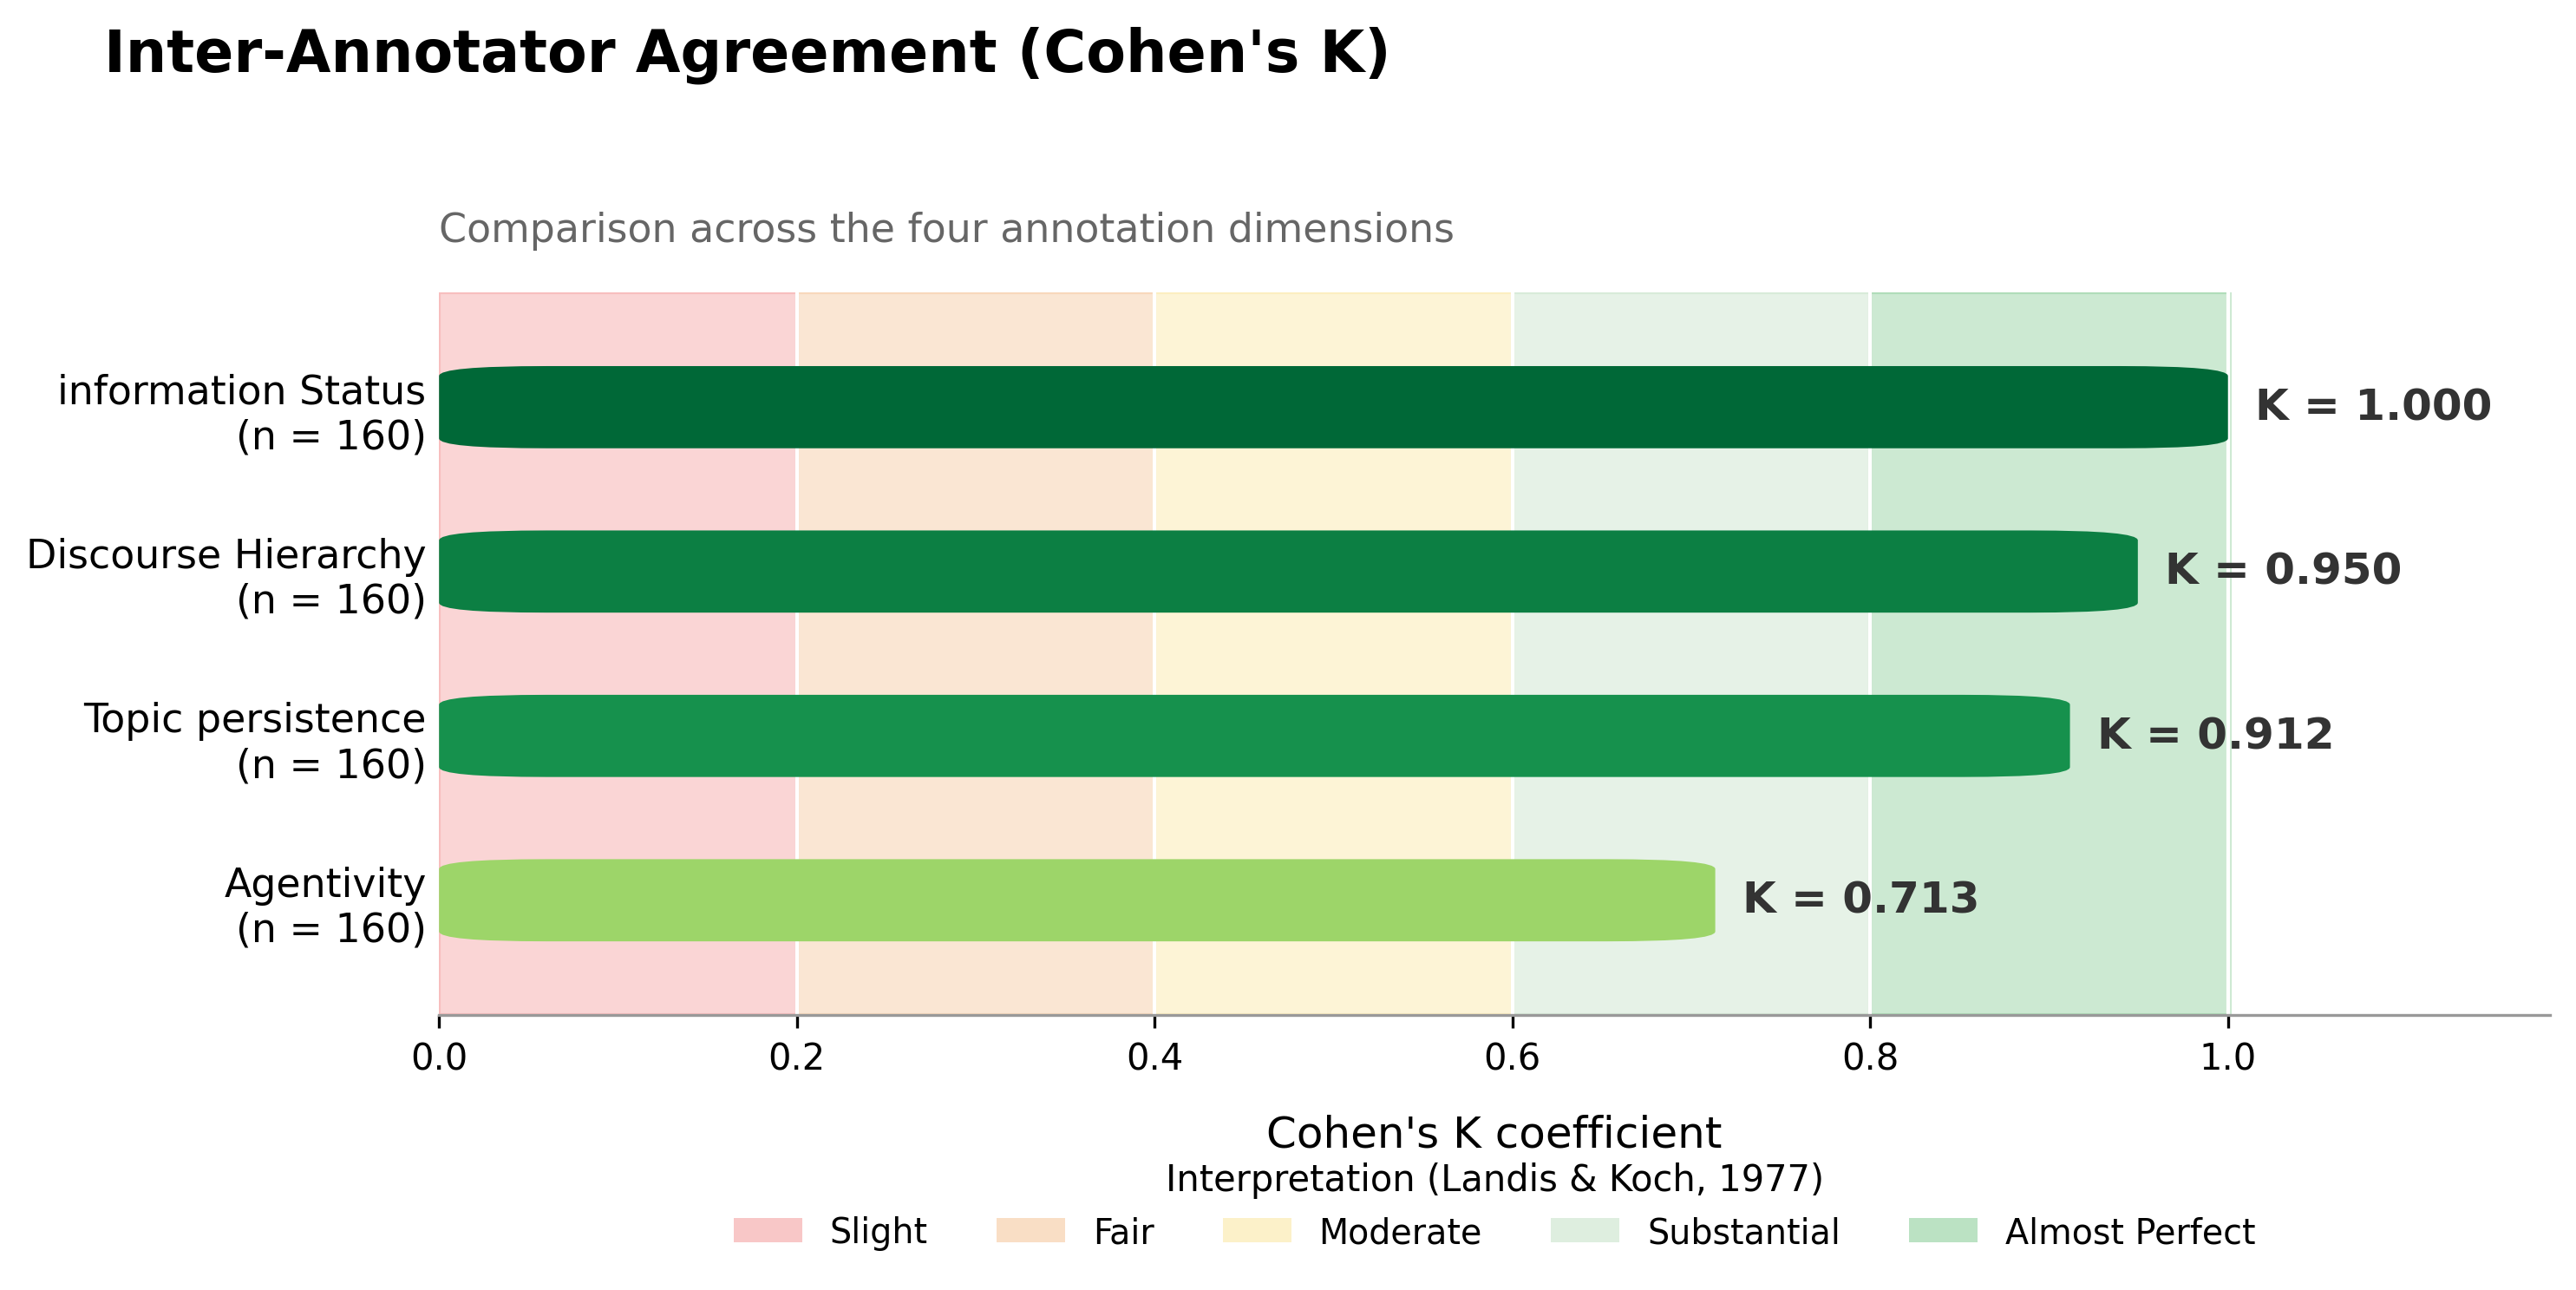

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# CELL 3 - chart (English labels)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

dati_ordinati = sorted(dati, key=lambda x: x[1])
labels = [d[0] for d in dati_ordinati]
values = [d[1] for d in dati_ordinati]
ns     = [d[2] for d in dati_ordinati]

bande = [
    (0.00, 0.20, "Slight",          "#f4a3a3"),
    (0.20, 0.40, "Fair",            "#f6c89f"),
    (0.40, 0.60, "Moderate",        "#fbe8a6"),
    (0.60, 0.80, "Substantial",     "#c9e4ca"),
    (0.80, 1.001, "Almost Perfect", "#8fcf9c"),
]

plt.rcParams["font.family"] = "DejaVu Sans"
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
y_pos = np.arange(len(labels))

for start, end, name, color in bande:
    ax.axvspan(start, end, color=color, alpha=0.45, zorder=0)

cmap = plt.colormaps["RdYlGn"]
bar_height = 0.5
for i, (label, val) in enumerate(zip(labels, values)):
    color = cmap(val)
    ax.add_patch(FancyBboxPatch(
        (0, i - bar_height/2), val, bar_height,
        boxstyle="round,pad=0,rounding_size=0.06",
        linewidth=0, facecolor=color, zorder=3
    ))
    ax.text(val + 0.015, i, f"K = {val:.3f}",
            va="center", ha="left", fontsize=12, fontweight="bold",
            color="#333333", zorder=4)

ytick_labels = [f"{l}\n(n = {n})" for l, n in zip(labels, ns)]
ax.set_yticks(y_pos)
ax.set_yticklabels(ytick_labels, fontsize=11)

for x in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.axvline(x, color="white", linewidth=1, zorder=1)

ax.set_xlim(0, 1.18)
ax.set_ylim(-0.7, len(labels) - 0.3)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlabel("Cohen's K coefficient", fontsize=12, labelpad=10)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#999999")
ax.tick_params(axis="y", length=0)

fig.suptitle("Inter-Annotator Agreement (Cohen's K)", fontsize=16,
              fontweight="bold", x=0.045, ha="left", y=0.985)
ax.set_title("Comparison across the four annotation dimensions",
              fontsize=11, color="#666666", loc="left", pad=14)

handles = [mpatches.Patch(facecolor=c, alpha=0.6, label=n) for _, _, n, c in bande]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.16),
          ncol=5, frameon=False, fontsize=9.5, title="Interpretation (Landis & Koch, 1977)",
          title_fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("kappa_chart.png", dpi=300, bbox_inches="tight")
plt.savefig("kappa_chart.pdf", bbox_inches="tight")
plt.show()

from google.colab import files as colab_files
colab_files.download("kappa_chart.png")
colab_files.download("kappa_chart.pdf")